#### Heart beat predictor - recurrent neural network model

In [18]:
from typing import Literal

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import keras
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [2]:
# set random seeds
tf.random.set_seed(42)
keras.utils.set_random_seed(42)
np.random.seed(42)

In [3]:
# Zadanie 1

path = "ECG5000.csv"

rows = []
with open(path, "r") as f:
    for line in f.readlines():
        data, _, label = line.partition(":")
        row = {i: float(val) for i, val in enumerate(data.split(","))}
        row["type"] = int(label.strip())
        rows.append(row)

df = pd.DataFrame(rows)

# Convert labels with boolean arithmetic, pre encoding we have 1 as healthy rythm and values 2,3,4,5 as four labels of different anomalies types.
# We create a series of booleans, if value is not 1 - True convert it to int (1), and for healthy label 1 we got False converted to int 0
df["type"] = (df["type"] != 1).astype(int)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Columns: 141 entries, 0 to type
dtypes: float64(140), int64(1)
memory usage: 5.4 MB


In [5]:
df.head(5)

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,type
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,0


In [6]:
df.tail(5)

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,type
4995,-1.122969,-2.252925,-2.867628,-3.358605,-3.167849,-2.638360,-1.664162,-0.935655,-0.866953,-0.645363,...,-0.472419,-1.310147,-2.029521,-3.221294,-4.176790,-4.009720,-2.874136,-2.008369,-1.808334,1
4996,-0.547705,-1.889545,-2.839779,-3.457912,-3.929149,-3.966026,-3.492560,-2.695270,-1.849691,-1.374321,...,1.258419,1.907530,2.280888,1.895242,1.437702,1.193433,1.261335,1.150449,0.804932,1
4997,-1.351779,-2.209006,-2.520225,-3.061475,-3.065141,-3.030739,-2.622720,-2.044092,-1.295874,-0.733839,...,-1.512234,-2.076075,-2.586042,-3.322799,-3.627311,-3.437038,-2.260023,-1.577823,-0.684531,1
4998,-1.124432,-1.905039,-2.192707,-2.904320,-2.900722,-2.761252,-2.569705,-2.043893,-1.490538,-0.938473,...,-2.821782,-3.268355,-3.634981,-3.168765,-2.245878,-1.262260,-0.443307,-0.559769,0.108568,1
4999,0.728813,0.192597,-0.733884,-1.779456,-2.345908,-2.977565,-3.380053,-3.417164,-3.030925,-2.313867,...,1.267275,1.678989,2.483389,2.569073,2.122891,1.753963,1.538975,1.713781,1.309382,1


In [7]:
class_distribution_df = df["type"].value_counts().sort_index()

class_distribution_df

type
0    2919
1    2081
Name: count, dtype: int64

Text(0.5, 1.0, 'Types of heart rhythm distribution in dataset')

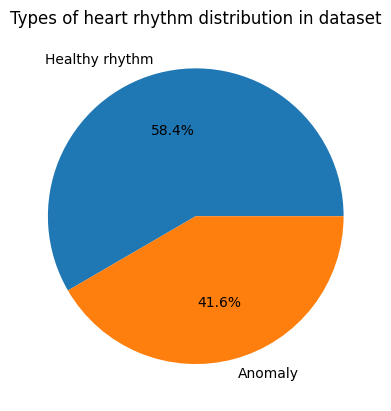

In [8]:
plt.pie(class_distribution_df, labels=["Healthy rhythm", "Anomaly"], autopct="%1.1f%%")
plt.title("Types of heart rhythm distribution in dataset")

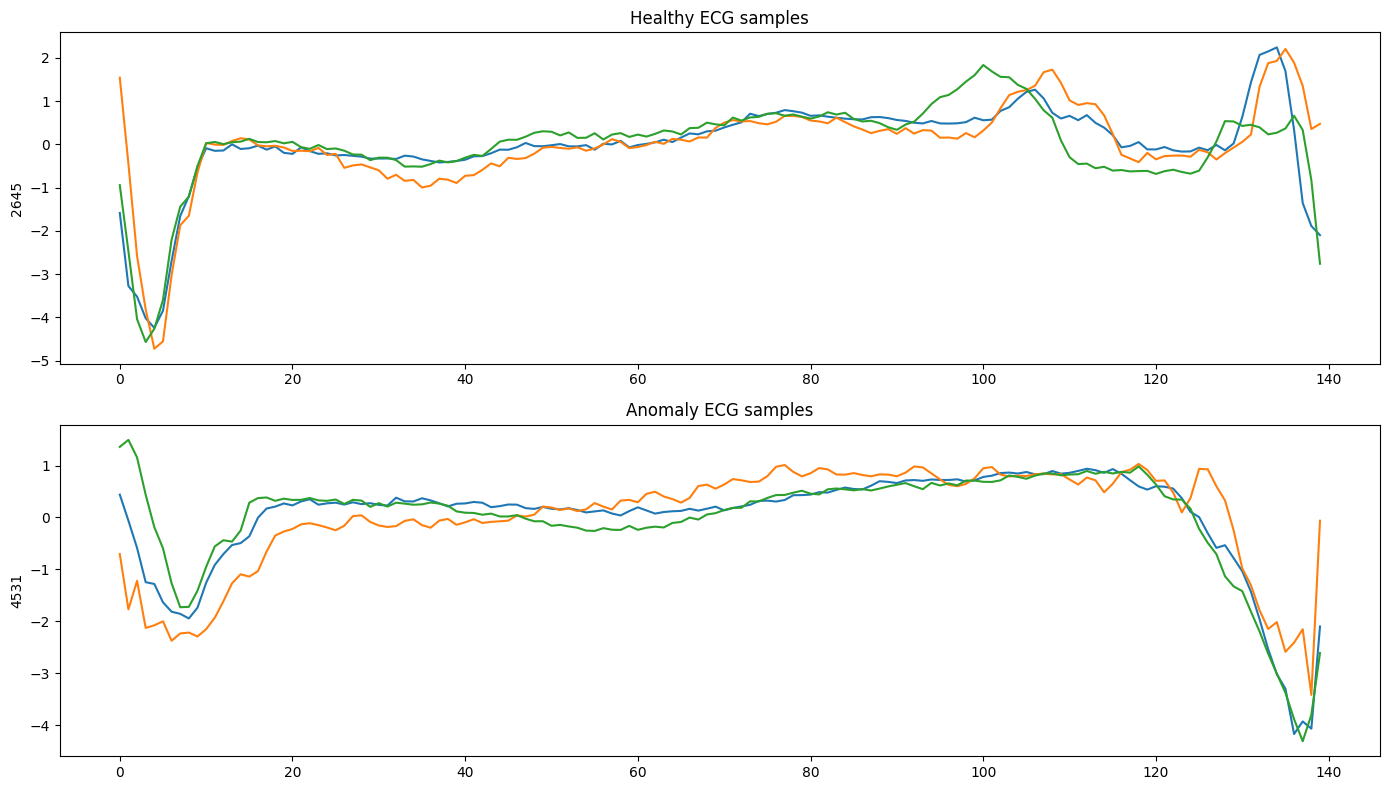

In [9]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(14,8))

# Decided for better readability to convert data from hourly to monthly using mean
rnd_healthy_samples = df.loc[df["type"] == 0].drop("type", axis=1).sample(n=3, random_state=42)
rnd_anomaly_sample = df.loc[df["type"] == 1].drop("type", axis=1).sample(n=3, random_state=42)

for _, row in rnd_healthy_samples.iterrows():
    sns.lineplot(data=row, ax=ax1)

for _, row in rnd_anomaly_sample.iterrows():
    sns.lineplot(data=row, ax=ax2)

ax1.set_title("Healthy ECG samples")
ax2.set_title("Anomaly ECG samples")
plt.tight_layout()

For such task correct metrics that should be used are F1 Score, precision, recall and working with roc-auc data as it's classification problem.

In [10]:
# Zadanie 2
X = df.drop(labels=["type"], axis=1)
y = df["type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = X_train_scaled.reshape(len(X_train_scaled), len(X_train_scaled[0]), 1)
X_test_scaled = X_test_scaled.reshape(len(X_test_scaled), len(X_test_scaled[0]), 1)

print(X_train_scaled.shape)
print(X_test_scaled.shape)
print(y_train.shape)
print(y_test.shape)

(3500, 140, 1)
(1500, 140, 1)
(3500,)
(1500,)


In [11]:
# Zadanie 3
sequence_length = X_train_scaled.shape[1]
n_features = X_train_scaled.shape[2]

model = keras.models.Sequential([
    keras.layers.Input(shape=(sequence_length, n_features)),
    keras.layers.LSTM(256,return_sequences=True),
    keras.layers.Dropout(rate=0.2),
    keras.layers.LSTM(128,return_sequences=True),
    keras.layers.Dropout(rate=0.2),
    keras.layers.LSTM(64, return_sequences=True),
    keras.layers.Dropout(rate=0.2),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.Dropout(rate=0.2),
    keras.layers.LSTM(8, return_sequences=False),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(1, activation="sigmoid"),
])

lr = 1e-4
opt = keras.optimizers.AdamW(learning_rate=lr)

model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

2026-06-23 23:32:37.834450: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-06-23 23:32:37.834477: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-06-23 23:32:37.834482: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1782250357.834491 3048971 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1782250357.834506 3048971 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 140, 256)       │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 140, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 140, 128)       │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 140, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 140, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 140, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 140, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 140, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 8)              │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 524,457 (2.00 MB)

 Trainable params: 524,457 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Zadanie 4

n_epochs = 60
batch_size = 100

fit = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=n_epochs,
    batch_size=batch_size,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ]
)

Epoch 1/60


2026-06-23 23:32:38.590216: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.5734 - loss: 0.6817 - val_accuracy: 0.5887 - val_loss: 0.6768
Epoch 2/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.5826 - loss: 0.6776 - val_accuracy: 0.5887 - val_loss: 0.6695
Epoch 3/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.5894 - loss: 0.6547 - val_accuracy: 0.7127 - val_loss: 0.5751
Epoch 4/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.9397 - loss: 0.3817 - val_accuracy: 0.9800 - val_loss: 0.2461
Epoch 5/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.9723 - loss: 0.2455 - val_accuracy: 0.9787 - val_loss: 0.2055
Epoch 6/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.9734 - loss: 0.2101 - val_accuracy: 0.9833 - val_loss: 0.1663
Epoch 7/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9771 - loss: 0.1864 - val_accuracy: 0.9807 - val_loss: 0.1495
Epoch 8/60
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.9749 - loss: 0.1749 - val_accuracy: 0.9820 - val_loss: 0.

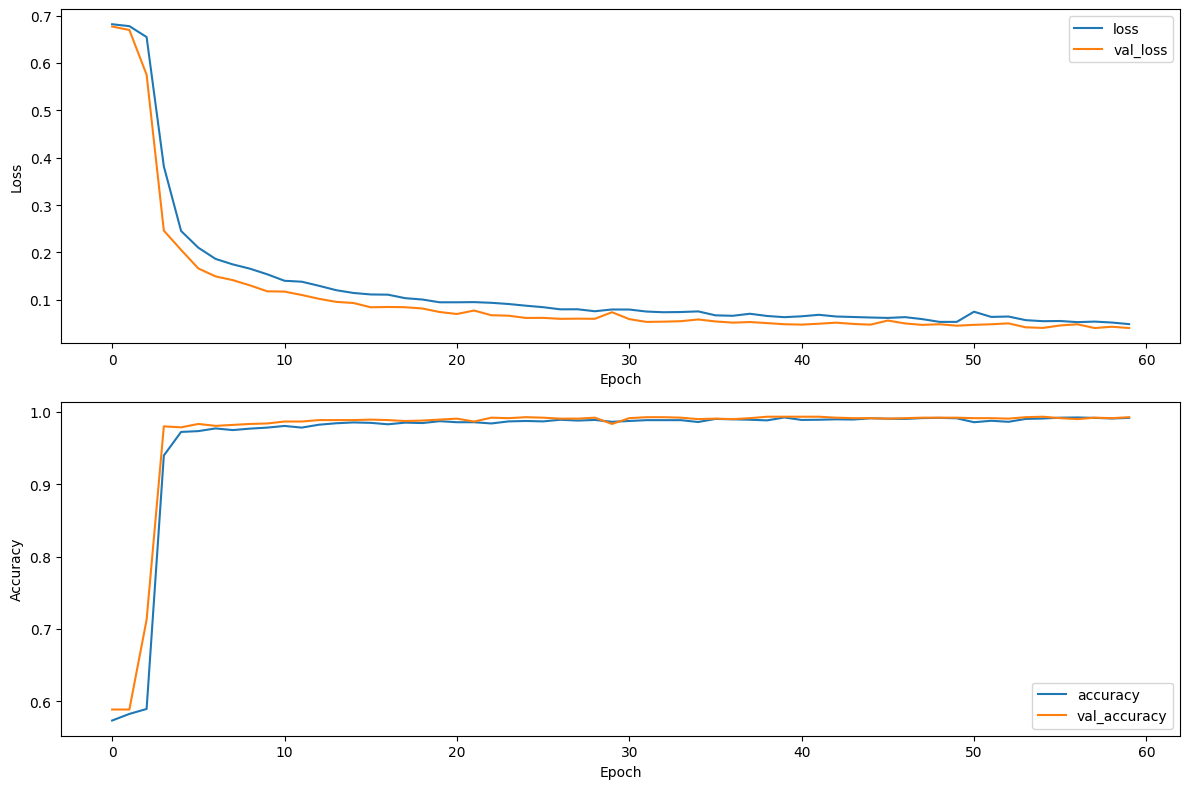

In [13]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(12, 8))

ax1.plot(fit.history['loss'], label='loss')
ax1.plot(fit.history['val_loss'], label='val_loss')
ax1.set_xlabel("Epoch")
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(fit.history['accuracy'], label='accuracy')
ax2.plot(fit.history['val_accuracy'], label='val_accuracy')
ax2.set_xlabel("Epoch")
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [14]:
# Zadanie 5

threshold = 0.3 # set threshold value for prediction validation

def get_model_metrics_df(y_true, y_pred, y_pred_proba, set_type: Literal["train", "test"]) -> pd.DataFrame:
    metrics_df = pd.DataFrame([
        {
            "accuracy": accuracy_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred),
            "recall": recall_score(y_true, y_pred),
            "roc_auc": roc_auc_score(y_true, y_pred_proba)
        },
    ])
    metrics_df.index = [f"LSTM_hr_anomaly_predictor_{set_type}_set"]
    return metrics_df

In [15]:
threshold = 0.3 # set threshold value for prediction validation

y_test_proba = model.predict(X_test_scaled)
y_test_pred = (y_test_proba >= threshold).astype(int)

get_model_metrics_df(y_test, y_test_pred, y_test_pred, set_type="test")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


,accuracy,f1,precision,recall,roc_auc
LSTM_hr_anomaly_predictor_test_set,0.992,0.990276,0.990276,0.990276,0.99174


We can observe threshold being fairly low - in the context of medical model this makes actual probability conversion into prediction stricter. It should be rather flagging healthy patient with anomaly (and inform the doctor about being more careful during examination) than missing real anomaly and marking it as healthy patient. 

This single variable is very important across all of this task. Modyfing it in real world scenario can be treated as 'auxiliary model hyperparameter' in my opinion.
In this case, such neural network performs very well no matter the threshold, but it should be acknowledged that in the context of this task, the baseline started from 0.5 and was decreased to some more real value of 0.3

In simple words this means that: if model has probabilities of 3 patients with values [0.45, 0.15, 0.78], it compares each value to the threshold. If probability of anomaly is greater than or equal to threshold (0.3) it converts it into label '1' - anomaly. We don't want to raise this threshold up, as the main metric for the task should be the recall - how many of all anomalies in validation set the model was able to correctly catch.

In [16]:
# Get predictions and metrics for training set too

y_train_proba = model.predict(X_train_scaled)
y_train_pred = (y_train_proba >= 0.3).astype(int)

get_model_metrics_df(y_train, y_train_pred, y_train_proba, set_type="train")

110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


,accuracy,f1,precision,recall,roc_auc
LSTM_hr_anomaly_predictor_train_set,0.993143,0.991786,0.993827,0.989754,0.997239


In [21]:
cm_train_set = confusion_matrix(y_true=y_train, y_pred=y_train_pred)
cm_test_set = confusion_matrix(y_true=y_test, y_pred=y_test_pred)

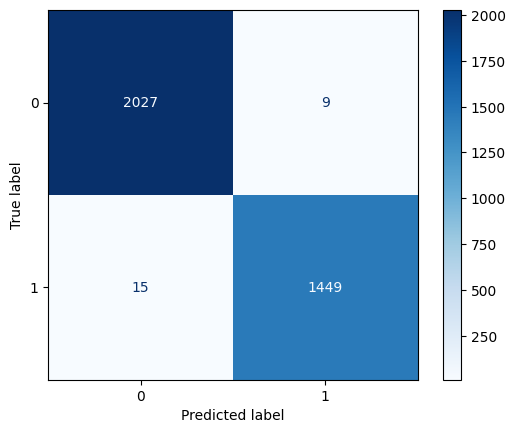

In [22]:
disp_train_cm = ConfusionMatrixDisplay(cm_train_set)
disp_train_cm.plot(cmap="Blues")

2027 correctly identified healthy heart sequences (True negative)
1449 correctly diagnosed anomalies (True positive)
9 incorrectly marked healthy people labeled as anomalies (False positive)
15 missed anomalies (False negative) those records are crucial for task like this

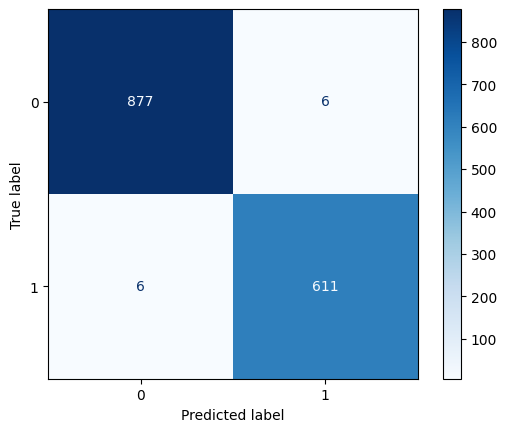

In [24]:
disp_test_cm = ConfusionMatrixDisplay(cm_test_set)
disp_test_cm.plot(cmap="Blues")

877 correctly identified healthy heart sequences (True negative)
611 correctly diagnosed anomalies (True positive)
6 incorrectly marked healthy people labeled as anomalies (False positive)
6 missed anomalies (False negative)

#### Discussion

For dataset like this RNN / LSTM is go to solution due to sequentail nature of data. Hearth rhythm is a pattern that has it's cruacial periods and behaviors that in those timestamps should happen and should have specific look.
LSTM model shares weights of timestamps and carries this long term memory of specifc rhythm, where MLP would treat this 140 entires of each hearth rhythm as independent features. RNN or LSTM is just a right tool for such task due to the 
sequential nature of the data. LSTM detects the anomaly no matter at which point of sequence it occures, this is the part where classic MLP would struggle.

With my specified model architecture model achieves very good metrics:
F1: 0.990276
Precision: 0.990276	
Recall: 0.990276	
Roc Auc: 0.99174


and due to dropout layers there is no overfitting during the training.